In [291]:
import pandas as pd 
import numpy as np 

In [292]:
data = pd.read_csv(r"C:\Users\dhana\Downloads\cleaned data\Single_view_of_ship.csv")

In [293]:
data.isnull().sum()

Name of Ship                                                    0
First Event of Ship                                             0
Last Event of Ship                                              0
Life time of Ship in months                                     0
recency of First Event                                          0
recency of Last Event                                           0
nLARP-Total                                                    55
nLARP_Closure                                                 243
nLARP_Status_Accepted                                          76
nLARP_Status_Open                                             277
nLARP_Status_Rejected                                         234
nLARP_Category_Safe act                                        65
nLARP_Category_Unsafe act                                      55
mLARP_Accepted-Safe act                                       104
mLARP_Accepted-Safe act-Closure                               273
mLARP_Acce

In [294]:
data.index = range(1, len(data) + 1)

In [295]:
data

,Name of Ship,First Event of Ship,Last Event of Ship,Life time of Ship in months,recency of First Event,recency of Last Event,nLARP-Total,nLARP_Closure,nLARP_Status_Accepted,nLARP_Status_Open,...,nADI_InjuryAccidentCategory_Lost Workday Case,nADI_InjuryAccidentCategory_Medical treatment case,nADI_InjuryAccidentCategory_Permanent partial disability,nADI_InjuryAccidentCategory_Permanent total disability,nADI_InjuryAccidentCategory_Restricted work case,nADI_InjuryAccidentCategory_Unknown,mADI_Closure-Occurrence-Report,mADI_Occurrence-Report,nInc,nCS
1,ACE SPAIN,2014-12-28,2017-03-06,26.251052,18.825849,39.787265,104.0,NaN,104.0,NaN,...,1.0,NaN,NaN,NaN,NaN,2.0,4.0,NaN,112.0,6216.0
2,ADITYA,2015-09-08,2020-05-23,56.477546,27.170989,1.215631,269.0,7.0,268.0,NaN,...,NaN,NaN,NaN,NaN,NaN,4.0,4.0,2.0,328.0,53628.0
3,AFRICAN SPOONBILL,2016-11-21,2019-12-29,37.224584,41.627138,6.012444,151.0,NaN,149.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,155.0,11935.0
4,AFRICAN TURACO,2016-03-19,2019-12-12,44.781207,33.511982,6.570977,71.0,NaN,70.0,NaN,...,NaN,NaN,NaN,NaN,NaN,6.0,6.0,2.0,94.0,4371.0
5,AL-BETROLEYA,2016-01-03,2020-05-19,52.502105,31.015011,1.347050,278.0,NaN,276.0,NaN,...,NaN,NaN,NaN,NaN,NaN,7.0,5.0,2.0,334.0,55611.0
6,ALAM MUTIARA,2013-06-03,2016-04-20,34.563338,0.000000,50.300828,8.0,NaN,NaN,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,55.0
7,AM OCEAN PRIDE,2016-11-10,2020-02-24,39.458716,41.265734,4.139715,158.0,NaN,153.0,NaN,...,1.0,NaN,NaN,NaN,NaN,4.0,10.0,NaN,190.0,17955.0
8,AM OCEAN SILVER,2017-12-13,2020-05-05,28.715169,54.341978,1.807019,152.0,NaN,150.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,17020.0
9,ANNE METTE BULKER,2015-09-18,2019-12-30,51.385039,27.499538,5.979589,249.0,1.0,245.0,NaN,...,NaN,NaN,NaN,NaN,NaN,5.0,6.0,NaN,255.0,32385.0
10,ANNEMETTE BULKER,2015-10-24,2020-05-31,55.229060,28.682314,0.952792,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,2628.0


In [296]:
null_counts = data.isnull().sum()
print(null_counts.sort_values(ascending=False))

mNM_NM-R-ICD-ICT                                              328
nADI_Incident Category_Critical potential - Near miss         328
mNM_NM                                                        328
nNM_External authority reporting required_Yes                 328
nNM_Further Investigation Required_Yes                        328
nADI_InjuryAccidentCategory_Permanent total disability        328
nNM_Investigation Completion                                  328
nNM_Investigation Commenced                                   328
mLARP_Rejected-Safe act-Closure                               326
nADI_InjuryAccidentCategory_Permanent partial disability      325
nNM_Incident_Category_Potential_Others                        325
mLARP_Rejected-Unsafe act-Closure                             321
nADI_Incident Category_Catastrophic or extremely harmful      317
nADI_Possibility Recurrence_Unknown                           309
nADI_InjuryAccidentCategory_Fatality                          295
nADI_Leari

In [297]:
cols_to_drop = data.columns[data.isnull().sum() > 240]
print("Columns to drop:", cols_to_drop)
data = data.drop(columns=cols_to_drop)

Columns to drop: Index(['nLARP_Closure', 'nLARP_Status_Open', 'mLARP_Accepted-Safe act-Closure',
       'mLARP_Accepted-Unsafe act-Closure', 'mLARP_Open-Safe act',
       'mLARP_Open-Unsafe act', 'mLARP_Rejected-Safe act',
       'mLARP_Rejected-Safe act-Closure', 'mLARP_Rejected-Unsafe act',
       'mLARP_Rejected-Unsafe act-Closure', 'nNM_Investigation Commenced',
       'nNM_Investigation Completion', 'nNM_Closure',
       'nNM_Incident_Category_Potential_Others', 'nNM_Learning Potential_High',
       'nNM_Further Investigation Required_Yes',
       'nNM_External authority reporting required_Yes', 'mNM_NM',
       'mNM_NM-R-CL', 'mNM_NM-R-ICD-ICT', 'mNM_R',
       'nADI_SeverityOfIncident_High', 'nADI_Possibility Recurrence_Unknown',
       'nADI_Incident Category_Catastrophic or extremely harmful',
       'nADI_Incident Category_Critical or severe harm',
       'nADI_Incident Category_Critical potential - Near miss',
       'nADI_LeariningPotential_High', 'nADI_InjuryAccidentCatego

In [298]:
data

,Name of Ship,First Event of Ship,Last Event of Ship,Life time of Ship in months,recency of First Event,recency of Last Event,nLARP-Total,nLARP_Status_Accepted,nLARP_Status_Rejected,nLARP_Category_Safe act,...,nADI_Incident Category_Minor,nADI_LeariningPotential_Low,nADI_LeariningPotential_Medium,nADI_LeariningPotential_Unknown,nADI_InjuryAccidentCategory_First aid case,nADI_InjuryAccidentCategory_Unknown,mADI_Closure-Occurrence-Report,mADI_Occurrence-Report,nInc,nCS
1,ACE SPAIN,2014-12-28,2017-03-06,26.251052,18.825849,39.787265,104.0,104.0,NaN,14.0,...,3.0,2.0,2.0,NaN,1.0,2.0,4.0,NaN,112.0,6216.0
2,ADITYA,2015-09-08,2020-05-23,56.477546,27.170989,1.215631,269.0,268.0,1.0,33.0,...,3.0,1.0,1.0,3.0,2.0,4.0,4.0,2.0,328.0,53628.0
3,AFRICAN SPOONBILL,2016-11-21,2019-12-29,37.224584,41.627138,6.012444,151.0,149.0,2.0,123.0,...,1.0,NaN,NaN,1.0,NaN,1.0,1.0,NaN,155.0,11935.0
4,AFRICAN TURACO,2016-03-19,2019-12-12,44.781207,33.511982,6.570977,71.0,70.0,1.0,18.0,...,5.0,3.0,2.0,3.0,2.0,6.0,6.0,2.0,94.0,4371.0
5,AL-BETROLEYA,2016-01-03,2020-05-19,52.502105,31.015011,1.347050,278.0,276.0,2.0,36.0,...,4.0,3.0,NaN,4.0,NaN,7.0,5.0,2.0,334.0,55611.0
6,ALAM MUTIARA,2013-06-03,2016-04-20,34.563338,0.000000,50.300828,8.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,55.0
7,AM OCEAN PRIDE,2016-11-10,2020-02-24,39.458716,41.265734,4.139715,158.0,153.0,5.0,11.0,...,7.0,3.0,3.0,3.0,5.0,4.0,10.0,NaN,190.0,17955.0
8,AM OCEAN SILVER,2017-12-13,2020-05-05,28.715169,54.341978,1.807019,152.0,150.0,2.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.0,17020.0
9,ANNE METTE BULKER,2015-09-18,2019-12-30,51.385039,27.499538,5.979589,249.0,245.0,4.0,39.0,...,5.0,3.0,1.0,2.0,NaN,5.0,6.0,NaN,255.0,32385.0
10,ANNEMETTE BULKER,2015-10-24,2020-05-31,55.229060,28.682314,0.952792,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.0,2628.0


In [299]:
data = data.rename(columns={

    'name_of_ship': 'Ship_name',
    'first_event_of_ship': 'First_event_date',
    'last_event_of_ship': 'Last_event_date',
    'life_time_of_ship_in_months': 'Ship_lifetime_months',
    'recency_of_first_event': 'Days_since_first_event',
    'recency_of_last_event': 'dDays_since_last_event',

    'nlarp_total': 'Larp_total',
    'nlarp_closure': 'Larp_closed',
    'nlarp_status_accepted': 'Larp_accepted',
    'nlarp_status_rejected': 'Larp_rejected',
    'nlarp_category_safe_act': 'Larp_safe_act',
    'nlarp_category_unsafe_act': 'Larp_unsafe_act',

    'nnm_total': 'Near_miss_total',
    'nnm_near_miss': 'Near_miss_count',
    'nnm_report': 'Near_miss_reports',

    'ninc': 'Incident_count',
    'ncs': 'Closure_count',

    'madi_closure_occurrence_report': 'ADI_closed_reports',
    'madi_occurrence_report': 'ADI_reports'
})

In [300]:
data.columns = data.columns.str.replace('-', '_')


In [301]:
data.columns = data.columns.str.strip()


In [302]:
data.isnull().sum()

Name of Ship                                                    0
First Event of Ship                                             0
Last Event of Ship                                              0
Life time of Ship in months                                     0
recency of First Event                                          0
recency of Last Event                                           0
nLARP_Total                                                    55
nLARP_Status_Accepted                                          76
nLARP_Status_Rejected                                         234
nLARP_Category_Safe act                                        65
nLARP_Category_Unsafe act                                      55
mLARP_Accepted_Safe act                                       104
mLARP_Accepted_Unsafe act                                      88
nNM_Total                                                      10
nNM_Near Miss                                                  16
nNM_Report

In [303]:
data['Name of Ship'].isnull().sum()


np.int64(0)

In [304]:
data['Name of Ship'].nunique()


329

In [305]:
data['Name of Ship'].head()

1            ACE SPAIN
2               ADITYA
3    AFRICAN SPOONBILL
4       AFRICAN TURACO
5         AL-BETROLEYA
Name: Name of Ship, dtype: object

In [306]:
data['ship Name'] = data['Name of Ship'].str.strip()

In [307]:
data['ship Name'].value_counts().head()

ship Name
NEO              2
NORD PEAK        1
NORD MONTREAL    1
NORD JOY         1
NORD JEWEL       1
Name: count, dtype: int64

In [308]:
data['First Event of Ship'].isnull().sum()


np.int64(0)

In [309]:
data['First Event of Ship'].head()


1    2014-12-28
2    2015-09-08
3    2016-11-21
4    2016-03-19
5    2016-01-03
Name: First Event of Ship, dtype: object

In [310]:
data['First Event of Ship'] = pd.to_datetime(data['First Event of Ship'],errors='coerce')

In [311]:
data['Last Event of Ship'].isnull().sum()
data['Last Event of Ship'].head()

1    2017-03-06
2    2020-05-23
3    2019-12-29
4    2019-12-12
5    2020-05-19
Name: Last Event of Ship, dtype: object

In [312]:
data['Last Event of Ship'] = pd.to_datetime(data['Last Event of Ship'],errors='coerce')

In [313]:
data['Life time of Ship in months'].isnull().sum()
data['Life time of Ship in months'].describe()

count    329.000000
mean      27.367363
std       19.948938
min        0.032855
25%       10.086449
50%       22.308466
75%       45.076901
max       70.933695
Name: Life time of Ship in months, dtype: float64

In [314]:
data['Life time of Ship in months'].head()

1    26.251052
2    56.477546
3    37.224584
4    44.781207
5    52.502105
Name: Life time of Ship in months, dtype: float64

In [315]:
data.rename(columns={'Life time of Ship in months':'Ship Lifetime Months'}, inplace=True)

In [316]:
data.columns

Index(['Name of Ship', 'First Event of Ship', 'Last Event of Ship',
       'Ship Lifetime Months', 'recency of First Event',
       'recency of Last Event', 'nLARP_Total', 'nLARP_Status_Accepted',
       'nLARP_Status_Rejected', 'nLARP_Category_Safe act',
       'nLARP_Category_Unsafe act', 'mLARP_Accepted_Safe act',
       'mLARP_Accepted_Unsafe act', 'nNM_Total', 'nNM_Near Miss', 'nNM_Report',
       'nNM_Severity of incident_High', 'nNM_Severity of incident_Low',
       'nNM_Severity of incident_Medium', 'nNM_Severity of incident_Unknown',
       'nNM_Probability_of_Reoccurence_Likely_High_Medium_Moderate',
       'nNM_Probability_of_Reoccurence_Others',
       'nNM_Probability_of_Reoccurence_Unlikely_Low_Marginal',
       'nNM_Probability_of_Reoccurence_Very Likely_Very High',
       'nNM_Probability_of_Reoccurence_Very Unlikely_Very Low',
       'nNM_Incident_Category_Potential_Catastrophic_Major_Extreme',
       'nNM_Incident_Category_Potential_Critical_Severe',
       'nNM_Incid

In [317]:
data['Ship Lifetime Months'] = pd.to_numeric(data['Ship Lifetime Months'],errors='coerce')

In [318]:
data['Ship Lifetime Months'] = data['Ship Lifetime Months'].round(2)

In [319]:
data['recency of First Event'].isnull().sum()
data['recency of First Event'].head()

1    18.825849
2    27.170989
3    41.627138
4    33.511982
5    31.015011
Name: recency of First Event, dtype: float64

In [320]:
data.rename(columns={'recency of First Event': 'Recency First Event Days'}, inplace=True)

In [321]:
data['Recency First Event Days'] = data['Recency First Event Days'].round(2)

In [322]:
data['recency of Last Event'].isnull().sum()
data['recency of Last Event'].head()

1    39.787265
2     1.215631
3     6.012444
4     6.570977
5     1.347050
Name: recency of Last Event, dtype: float64

In [323]:
data.rename(columns={'recency of Last Event': 'Recency Last Event Days'}, inplace=True)

In [324]:
data['Recency Last Event Days'] = pd.to_numeric(data['Recency Last Event Days'],errors='coerce')

In [325]:
data['Recency Last Event Days'] = data['Recency Last Event Days'].round(2)

In [326]:
data.rename(columns={'nLARP_Total': 'Larp Total'}, inplace=True)

In [327]:
data['Larp Total'].isnull().sum()

np.int64(55)

In [328]:
data['Larp Total'].head()

1    104.0
2    269.0
3    151.0
4     71.0
5    278.0
Name: Larp Total, dtype: float64

In [329]:
data['Larp Total'] = pd.to_numeric(data['Larp Total'],errors='coerce')

In [330]:
data['Larp Total'] = data['Larp Total'].fillna(0)

In [331]:
data.rename(columns={'nLARP_Status_Accepted': 'Larp Accepted'}, inplace=True)

In [332]:
data['Larp Accepted'].head()

1    104.0
2    268.0
3    149.0
4     70.0
5    276.0
Name: Larp Accepted, dtype: float64

In [333]:
data['Larp Accepted'] = pd.to_numeric(data['Larp Accepted'],errors='coerce')

In [334]:
data['Larp Accepted'].isnull().sum()

np.int64(76)

In [335]:
data['Larp Accepted'] = data['Larp Accepted'].fillna(0)

In [336]:
data.rename(columns={'nLARP_Status_Rejected': 'Larp Rejected'}, inplace=True)

In [337]:
data['Larp Rejected'].head()

1    NaN
2    1.0
3    2.0
4    1.0
5    2.0
Name: Larp Rejected, dtype: float64

In [338]:
data['Larp Rejected'].isnull().sum()

np.int64(234)

In [339]:
data['Larp Rejected'] = data['Larp Rejected'].fillna(0)

In [340]:
data.rename(columns={'nLARP_Category_Safe act': 'Larp Safe Act'}, inplace=True)

In [341]:
data['Larp Safe Act'] = pd.to_numeric(data['Larp Safe Act'],errors='coerce')

In [342]:
data['Larp Safe Act'].isnull().sum()

np.int64(65)

In [343]:
data['Larp Safe Act'].head()

1     14.0
2     33.0
3    123.0
4     18.0
5     36.0
Name: Larp Safe Act, dtype: float64

In [344]:
data['Larp Safe Act'] = data['Larp Safe Act'].fillna(0)

In [345]:
data.rename(columns={'nLARP_Category_Unsafe act': 'Larp Unsafe Act'}, inplace=True)

In [346]:
data['Larp Unsafe Act'] = pd.to_numeric(data['Larp Unsafe Act'],errors='coerce')

In [347]:
data['Larp Unsafe Act'].head()

1     90.0
2    236.0
3     28.0
4     53.0
5    242.0
Name: Larp Unsafe Act, dtype: float64

In [348]:
data['Larp Unsafe Act'].isnull().sum()

np.int64(55)

In [349]:
data['Larp Unsafe Act'] = data['Larp Unsafe Act'].fillna(0)

In [350]:
data.rename(columns={'mLARP_Accepted_Safe act': 'Accepted Safe Act Flag'}, inplace=True)

In [351]:
data['Accepted Safe Act Flag'].head()

1     14.0
2     33.0
3    121.0
4     18.0
5     36.0
Name: Accepted Safe Act Flag, dtype: float64

In [352]:
data['Accepted Safe Act Flag'] = data['Accepted Safe Act Flag'].fillna(0)

In [353]:
data.rename(columns={'mLARP_Accepted_Unsafe act': 'Accepted Unsafe Act Flag'}, inplace=True)

In [354]:
data['Accepted Unsafe Act Flag'].head()

1     90.0
2    229.0
3     28.0
4     52.0
5    240.0
Name: Accepted Unsafe Act Flag, dtype: float64

In [355]:
data['Accepted Unsafe Act Flag'].isnull().sum()

np.int64(88)

In [356]:
data['Accepted Unsafe Act Flag'] = data['Accepted Unsafe Act Flag'].fillna(0)

In [357]:
data['nNM_Total'].isnull().sum()


np.int64(10)

In [358]:
data.rename(columns={'nNM_Total': 'Near Miss Total'}, inplace=True)

In [359]:
data['Near Miss Total'].head()

1     4.0
2    53.0
3     3.0
4    15.0
5    49.0
Name: Near Miss Total, dtype: float64

In [360]:
data['Near Miss Total'].isnull().sum()

np.int64(10)

In [361]:
data['Near Miss Total'] = pd.to_numeric(data['Near Miss Total'],errors='coerce')

In [362]:
data['Near Miss Total'] = data['Near Miss Total'].fillna(0)

In [363]:
data['nNM_Near Miss'].isnull().sum()


np.int64(16)

In [364]:
data.rename(columns={'nNM_Near Miss': 'Near Miss Count'}, inplace=True)

In [365]:
data['Near Miss Count'] = pd.to_numeric(data['Near Miss Count'],errors='coerce')

In [366]:
data['Near Miss Count'] = data['Near Miss Count'].fillna(0)

In [367]:
data['nNM_Report'].isnull().sum()


np.int64(10)

In [368]:
data.rename(columns={'nNM_Report': 'Near Miss Report'}, inplace=True)

In [369]:
data['Near Miss Report'] = pd.to_numeric(data['Near Miss Report'],errors='coerce')

In [370]:
data['Near Miss Report'] = data['Near Miss Report'].fillna(0)

In [371]:
data['Near Miss Report'].head()

1     4.0
2    53.0
3     3.0
4    15.0
5    49.0
Name: Near Miss Report, dtype: float64

In [372]:
severity_cols = [col for col in data.columns if 'nNM_Severity of incident' in col]

data['Incident Severity'] = data[severity_cols].idxmax(axis=1)

data['Incident Severity'] = data['Incident Severity'].str.replace('nNM_Severity of incident_', '')

data.drop(columns=severity_cols, inplace=True)

C:\Users\dhana\AppData\Local\Temp\ipykernel_15712\2917010883.py:3: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  data['Incident Severity'] = data[severity_cols].idxmax(axis=1)


In [373]:
data.rename(columns={
    'nNM_Probability_of_Reoccurence_Likely_High_Medium_Moderate': 'Probability Level'
}, inplace=True)

In [374]:
data['Incident Severity'].isnull().sum()

np.int64(10)

In [375]:
data['Incident Severity'].head()

1        Low
2    Unknown
3     Medium
4     Medium
5        Low
Name: Incident Severity, dtype: object

In [376]:
data['Incident Severity'] = data['Incident Severity'].fillna('Unknown')

In [377]:
data['Probability Level'].head()

1     3.0
2    11.0
3     3.0
4     9.0
5    20.0
Name: Probability Level, dtype: float64

In [378]:
data['Probability Level'].isnull().sum()

np.int64(41)

In [379]:
data['Probability Level'] = data['Probability Level'].fillna(0)

In [380]:
prob_cols = [col for col in data.columns if 'nNM_Probability_of_Reoccurence' in col]

data[prob_cols].isnull().sum()

nNM_Probability_of_Reoccurence_Others                    232
nNM_Probability_of_Reoccurence_Unlikely_Low_Marginal      41
nNM_Probability_of_Reoccurence_Very Likely_Very High     150
nNM_Probability_of_Reoccurence_Very Unlikely_Very Low     98
dtype: int64

In [381]:
prob_cols = [col for col in data.columns if 'nNM_Probability_of_Reoccurence' in col]

data['Incident Probability'] = data[prob_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Incident Probability'] = data['Incident Probability'].str.replace(
    'nNM_Probability_of_Reoccurence_', ''
)

In [382]:
data.drop(columns=prob_cols, inplace=True)

In [383]:
data['Incident Probability'].isnull().sum()

np.int64(0)

In [384]:
cat_cols = [col for col in data.columns if 'nNM_Incident_Category_Potential' in col]

data[cat_cols].isnull().all(axis=1).sum()

np.int64(10)

In [385]:
cat_cols = [col for col in data.columns if 'nNM_Incident_Category_Potential' in col]

data['Incident Potential'] = data[cat_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Incident Potential'] = data['Incident Potential'].str.replace(
    'nNM_Incident_Category_Potential_', ''
)

In [386]:
data.drop(columns=cat_cols, inplace=True)

In [387]:
data['Incident Potential'].head()

1    Minor_Low_Slight
2    Minor_Low_Slight
3    Minor_Low_Slight
4    Minor_Low_Slight
5    Minor_Low_Slight
Name: Incident Potential, dtype: object

In [388]:
learn_cols = [col for col in data.columns if 'nNM_Learning Potential' in col]

data['Learning Potential'] = data[learn_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Learning Potential'] = data['Learning Potential'].str.replace(
    'nNM_Learning Potential_', ''
).str.replace('_', ' ')

In [389]:
data.drop(columns=learn_cols, inplace=True)

In [390]:
invest_cols = [col for col in data.columns if 'nNM_Further Investigation Required' in col]

data['Further Investigation'] = data[invest_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Further Investigation'] = data['Further Investigation'].str.replace(
    'nNM_Further Investigation Required_', ''
).str.replace('_', ' ')

In [391]:
data.drop(columns=invest_cols, inplace=True)

In [392]:
oil_cols = [col for col in data.columns if 'nNM_Incident communicated to oil majors' in col]

data['Oil Majors Communication'] = data[oil_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Oil Majors Communication'] = data['Oil Majors Communication'].str.replace(
    'nNM_Incident communicated to oil majors_', ''
).str.replace('_', ' ')

In [393]:
data.drop(columns=oil_cols, inplace=True)

In [394]:
ext_cols = [col for col in data.columns if 'nNM_External authority reporting required' in col]

data['External Reporting Required'] = data[ext_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['External Reporting Required'] = data['External Reporting Required'].str.replace(
    'nNM_External authority reporting required_', ''
).str.replace('_', ' ')

In [395]:
data.drop(columns=ext_cols, inplace=True)

In [396]:
share_cols = [col for col in data.columns if 'nNM_Potential incident to be shared with industry' in col]

data['Industry Shared'] = data[share_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['Industry Shared'] = data['Industry Shared'].str.replace(
    'nNM_Potential incident to be shared with industry_', ''
).str.replace('_', ' ')

In [397]:
data.drop(columns=share_cols, inplace=True)

In [398]:
data.rename(columns={
    'nADI_Occurrence': 'ADI Occurrence'
}, inplace=True)

data['ADI Occurrence'] = pd.to_numeric(data['ADI Occurrence'], errors='coerce')

data['ADI Occurrence'] = data['ADI Occurrence'].fillna(0)

data = data[data['ADI Occurrence'] >= 0]

data['ADI Occurrence'] = data['ADI Occurrence'].astype(int)

In [399]:
data.rename(columns={
    'nADI_Total': 'ADI Total'
}, inplace=True)

data['ADI Total'] = pd.to_numeric(data['ADI Total'], errors='coerce')

data['ADI Total'] = data['ADI Total'].fillna(0)

data = data[data['ADI Total'] >= 0]

data['ADI Total'] = data['ADI Total'].astype(int)

In [400]:
data[['Industry Shared', 'ADI Total', 'ADI Occurrence']].head()

,Industry Shared,ADI Total,ADI Occurrence
1,Unknown,4,4
2,Unknown,6,6
3,Unknown,1,1
4,Unknown,8,8
5,Unknown,7,7


In [401]:
data.rename(columns={
    'nADI_Report': 'ADI Report'
}, inplace=True)

data['ADI Report'] = pd.to_numeric(data['ADI Report'], errors='coerce')

data['ADI Report'] = data['ADI Report'].fillna(0)

data = data[data['ADI Report'] >= 0]

data['ADI Report'] = data['ADI Report'].astype(int)

In [402]:
data.rename(columns={
    'nADI_Closure': 'ADI Closure'
}, inplace=True)

data['ADI Closure'] = pd.to_numeric(data['ADI Closure'], errors='coerce')

data['ADI Closure'] = data['ADI Closure'].fillna(0)

data = data[data['ADI Closure'] >= 0]

data['ADI Closure'] = data[['ADI Closure', 'ADI Report']].min(axis=1)

data['ADI Closure'] = data['ADI Closure'].astype(int)

In [403]:
data['ADI Closure Rate'] = data['ADI Closure'] / data['ADI Report']
data['ADI Closure Rate'] = data['ADI Closure Rate'].fillna(0)

In [404]:
adi_sev_cols = [col for col in data.columns if 'nADI_SeverityOfIncident' in col]

In [405]:
data['ADI Severity'] = data[adi_sev_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Severity'] = data['ADI Severity'].str.replace(
    'nADI_SeverityOfIncident_', ''
)

In [406]:
data.drop(columns=adi_sev_cols, inplace=True)

In [407]:
data['ADI Severity'] = data['ADI Severity'].str.replace('_', ' ')

In [408]:
data[['ADI Report', 'ADI Closure', 'ADI Severity']].head()

,ADI Report,ADI Closure,ADI Severity
1,4,4,Medium
2,6,4,Low
3,1,1,Medium
4,8,6,Medium
5,7,5,Medium


In [409]:
poss_cols = [col for col in data.columns if 'nADI_Possibility Recurrence' in col]

data[poss_cols].isnull().sum()

nADI_Possibility Recurrence_Likely           173
nADI_Possibility Recurrence_Unlikely         129
nADI_Possibility Recurrence_Very likely      237
nADI_Possibility Recurrence_Very unlikely    172
dtype: int64

In [410]:
poss_cols = [col for col in data.columns if 'nADI_Possibility Recurrence' in col]

data['ADI Recurrence'] = data[poss_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Recurrence'] = data['ADI Recurrence'].str.replace(
    'nADI_Possibility Recurrence_', ''
).str.replace('_', ' ')

In [411]:
data.drop(columns=poss_cols, inplace=True)

In [412]:
adi_cat_cols = [col for col in data.columns if 'nADI_Incident Category' in col]

In [413]:
data['ADI Incident Category'] = data[adi_cat_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Incident Category'] = data['ADI Incident Category'].str.replace(
    'nADI_Incident Category_', ''
).str.replace('_', ' ')

In [414]:
data.drop(columns=adi_cat_cols, inplace=True)

In [415]:
data[['ADI Recurrence', 'ADI Incident Category']].head()

,ADI Recurrence,ADI Incident Category
1,Very unlikely,Minor
2,Likely,Minor
3,Very likely,Minor
4,Unlikely,Minor
5,Unlikely,Minor


In [416]:
adi_cat_cols = [col for col in data.columns if 'nADI_Incident Category' in col]

data['ADI Incident Category'] = data[adi_cat_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Incident Category'] = data['ADI Incident Category'].str.replace(
    'nADI_Incident Category_', ''
).str.replace('_', ' ')

In [417]:
data.drop(columns=adi_cat_cols, inplace=True)

In [418]:
adi_learn_cols = [col for col in data.columns if 'nADI_LeariningPotential' in col]

data['ADI Learning Potential'] = data[adi_learn_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Learning Potential'] = data['ADI Learning Potential'].str.replace(
    'nADI_LeariningPotential_', ''
).str.replace('_', ' ')

In [419]:
data.drop(columns=adi_learn_cols, inplace=True)

In [420]:
data[['ADI Incident Category', 'ADI Learning Potential']].head()

,ADI Incident Category,ADI Learning Potential
1,Unknown,Low
2,Unknown,Unknown
3,Unknown,Unknown
4,Unknown,Low
5,Unknown,Unknown


In [421]:
inj_cols = [col for col in data.columns if 'nADI_InjuryAccidentCategory' in col]

data['ADI Injury Category'] = data[inj_cols].apply(
    lambda row: row.idxmax() if row.sum() > 0 else 'Unknown',
    axis=1
)

data['ADI Injury Category'] = data['ADI Injury Category'].str.replace(
    'nADI_InjuryAccidentCategory_', ''
).str.replace('_', ' ')

In [422]:
data.drop(columns=inj_cols, inplace=True)

In [423]:
data.rename(columns={'nInc': 'Total Incidents'}, inplace=True)

data['Total Incidents'] = pd.to_numeric(data['Total Incidents'], errors='coerce')

data['Total Incidents'] = data['Total Incidents'].fillna(0)

data = data[data['Total Incidents'] >= 0]

data['Total Incidents'] = data['Total Incidents'].astype(int)

In [424]:
data.rename(columns={'nCS': 'Closure Count'}, inplace=True)

data['Closure Count'] = pd.to_numeric(data['Closure Count'], errors='coerce')

data['Closure Count'] = data['Closure Count'].fillna(0)

data = data[data['Closure Count'] >= 0]

data['Closure Count'] = data['Closure Count'].astype(int)

In [425]:
data['Closure Rate'] = data['Closure Count'] / data['Total Incidents']
data['Closure Rate'] = data['Closure Rate'].fillna(0)

In [426]:
data[['ADI Injury Category', 'Total Incidents', 'Closure Count']].head()

,ADI Injury Category,Total Incidents,Closure Count
1,Unknown,112,6216
2,Unknown,328,53628
3,Unknown,155,11935
4,Unknown,94,4371
5,Unknown,334,55611


In [427]:
data.isnull().sum()

Name of Ship                        0
First Event of Ship                 0
Last Event of Ship                  0
Ship Lifetime Months                0
Recency First Event Days            0
Recency Last Event Days             0
Larp Total                          0
Larp Accepted                       0
Larp Rejected                       0
Larp Safe Act                       0
Larp Unsafe Act                     0
Accepted Safe Act Flag              0
Accepted Unsafe Act Flag            0
Near Miss Total                     0
Near Miss Count                     0
Near Miss Report                    0
Probability Level                   0
mNM_NM_R                           19
ADI Total                           0
ADI Occurrence                      0
ADI Report                          0
ADI Closure                         0
mADI_Closure_Occurrence_Report     87
mADI_Occurrence_Report            207
Total Incidents                     0
Closure Count                       0
ship Name   

In [428]:
data.rename(columns={
    'mNM_NM_R': 'NM R Flag'
}, inplace=True)

In [429]:
data['NM R Flag'] = data['NM R Flag'].fillna(0)

In [430]:
data.rename(columns={
    'mADI_Closure_Occurrence_Report': 'ADI Closure Report Flag'
}, inplace=True)

In [431]:
data['ADI Closure Report Flag'].isnull().sum()

np.int64(87)

In [432]:
data['ADI Closure Report Flag'].head()

1    4.0
2    4.0
3    1.0
4    6.0
5    5.0
Name: ADI Closure Report Flag, dtype: float64

In [433]:
data['ADI Closure Report Flag'] = data['ADI Closure Report Flag'].fillna(0)

In [434]:
data.rename(columns={
    'mADI_Occurrence_Report': 'ADI Occurrence Report'
}, inplace=True)

In [435]:
data['ADI Occurrence Report'].head()

1    NaN
2    2.0
3    NaN
4    2.0
5    2.0
Name: ADI Occurrence Report, dtype: float64

In [436]:
data['ADI Occurrence Report'].value_counts()

ADI Occurrence Report
1.0    70
2.0    35
3.0     9
4.0     6
7.0     2
Name: count, dtype: int64

In [437]:
data['ADI Occurrence Report'] = data['ADI Occurrence Report'].fillna(0)

In [438]:
data.isnull().sum()

Name of Ship                   0
First Event of Ship            0
Last Event of Ship             0
Ship Lifetime Months           0
Recency First Event Days       0
Recency Last Event Days        0
Larp Total                     0
Larp Accepted                  0
Larp Rejected                  0
Larp Safe Act                  0
Larp Unsafe Act                0
Accepted Safe Act Flag         0
Accepted Unsafe Act Flag       0
Near Miss Total                0
Near Miss Count                0
Near Miss Report               0
Probability Level              0
NM R Flag                      0
ADI Total                      0
ADI Occurrence                 0
ADI Report                     0
ADI Closure                    0
ADI Closure Report Flag        0
ADI Occurrence Report          0
Total Incidents                0
Closure Count                  0
ship Name                      0
Incident Severity              0
Incident Probability           0
Incident Potential             0
Learning P

C:\Users\dhana\AppData\Local\Temp\ipykernel_15712\4159518640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


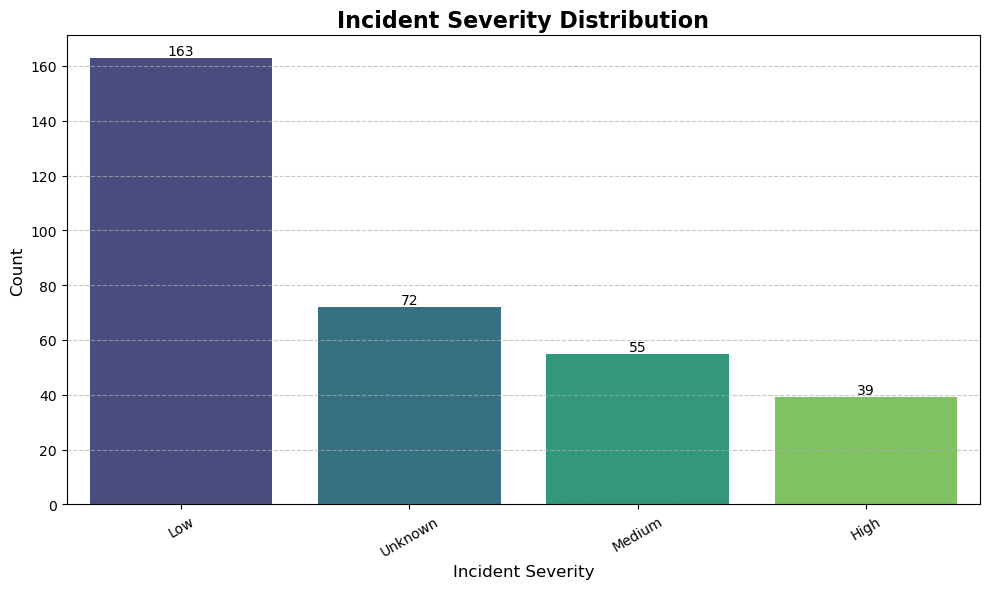

In [459]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Incident Severity',
    data=data,
    order=data['Incident Severity'].value_counts().index,
    palette='viridis'
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Incident Severity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Incident Severity", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

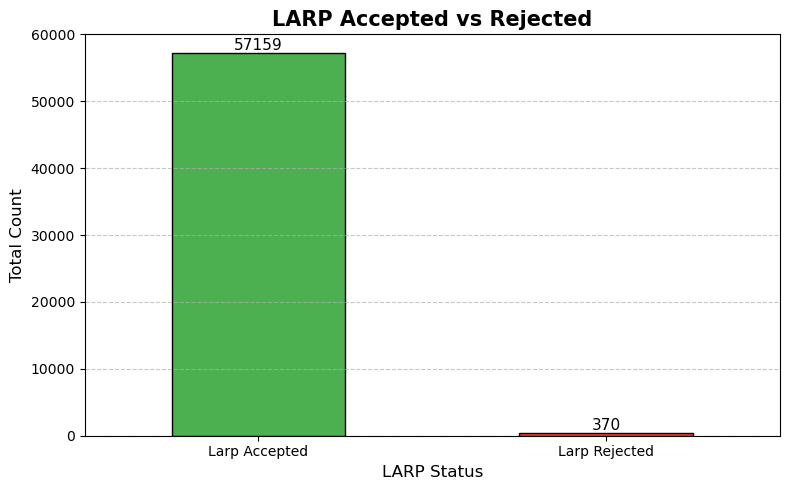

In [460]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = data[['Larp Accepted', 'Larp Rejected']].sum().plot(
    kind='bar',
    color=['#4CAF50', '#F44336'],  # green = accepted, red = rejected
    edgecolor='black'
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title("LARP Accepted vs Rejected", fontsize=15, fontweight='bold')
plt.xlabel("LARP Status", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

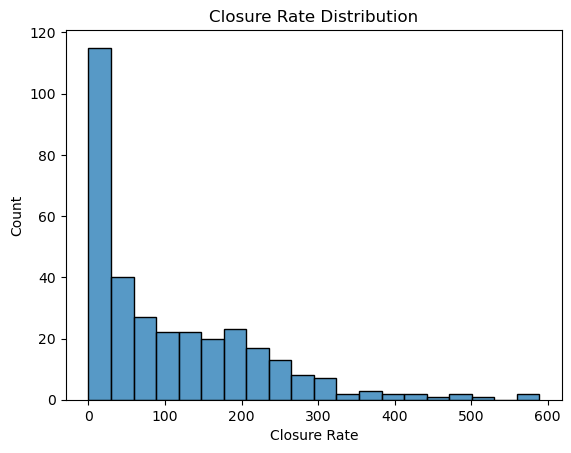

In [441]:
sns.histplot(data['Closure Rate'], bins=20)
plt.title("Closure Rate Distribution")
plt.show()

In [442]:
pd.crosstab(data['Incident Probability'], data['Incident Severity'])

Incident Severity,High,Low,Medium,Unknown
Incident Probability,,,,
Others,1,1,3,12
Unknown,4,2,1,14
Unlikely_Low_Marginal,27,136,47,35
Very Likely_Very High,4,12,2,5
Very Unlikely_Very Low,3,12,2,6


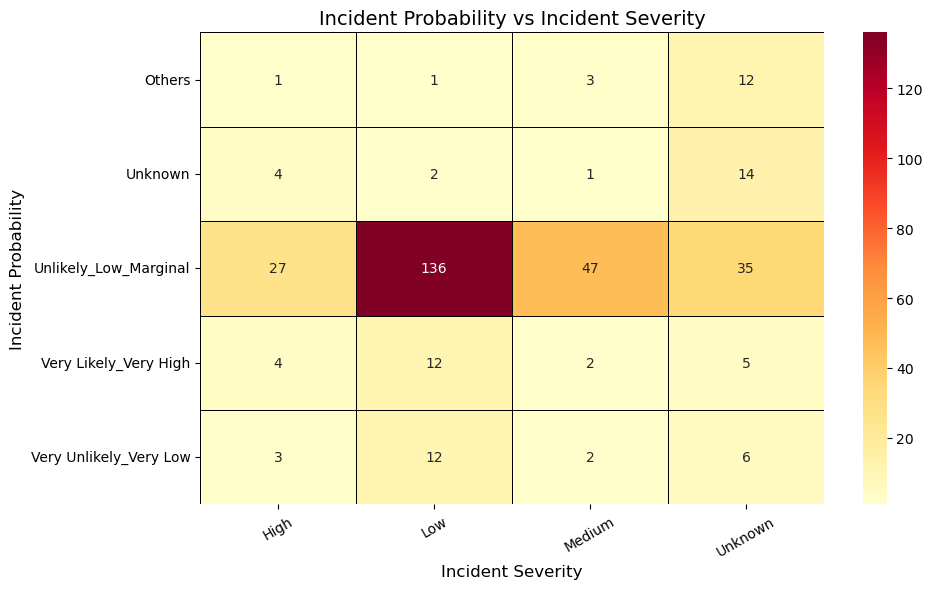

In [443]:


ct = pd.crosstab(
    data['Incident Probability'],
    data['Incident Severity']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    ct,
    annot=True,
    fmt='d',                 
    cmap='YlOrRd',
    linewidths=0.5,          
    linecolor='black',
    cbar=True                
)

plt.title("Incident Probability vs Incident Severity", fontsize=14)
plt.xlabel("Incident Severity", fontsize=12)
plt.ylabel("Incident Probability", fontsize=12)

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

C:\Users\dhana\AppData\Local\Temp\ipykernel_15712\3732976251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


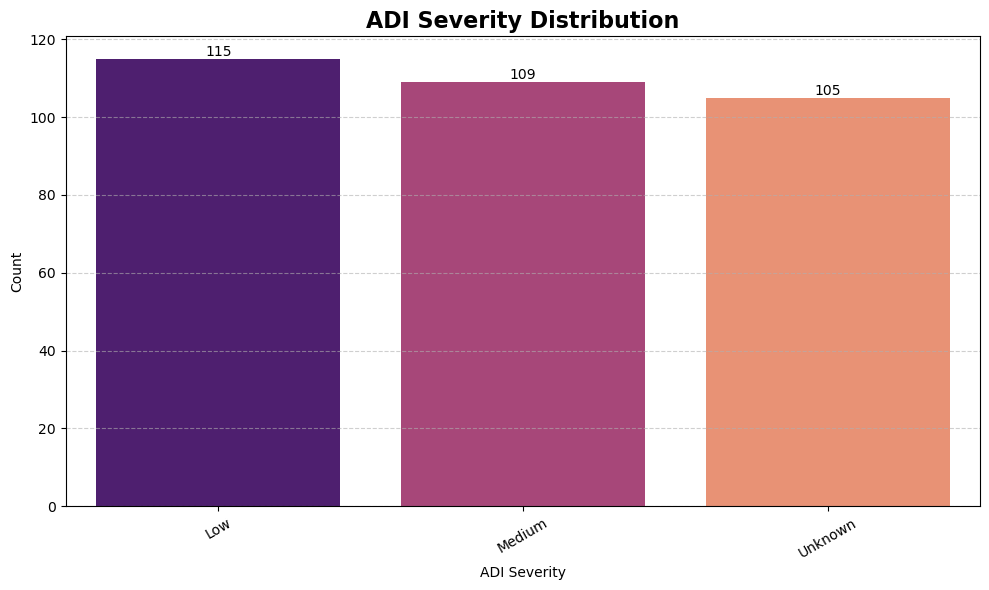

In [461]:
plt.figure(figsize=(10,6))

order = data['ADI Severity'].value_counts().index

ax = sns.countplot(
    x='ADI Severity',
    data=data,
    order=order,
    palette='magma'
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("ADI Severity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("ADI Severity")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

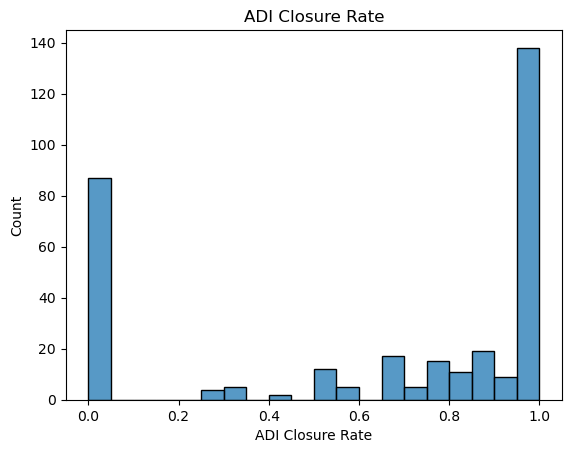

In [445]:
sns.histplot(data['ADI Closure Rate'], bins=20)
plt.title("ADI Closure Rate")
plt.show()

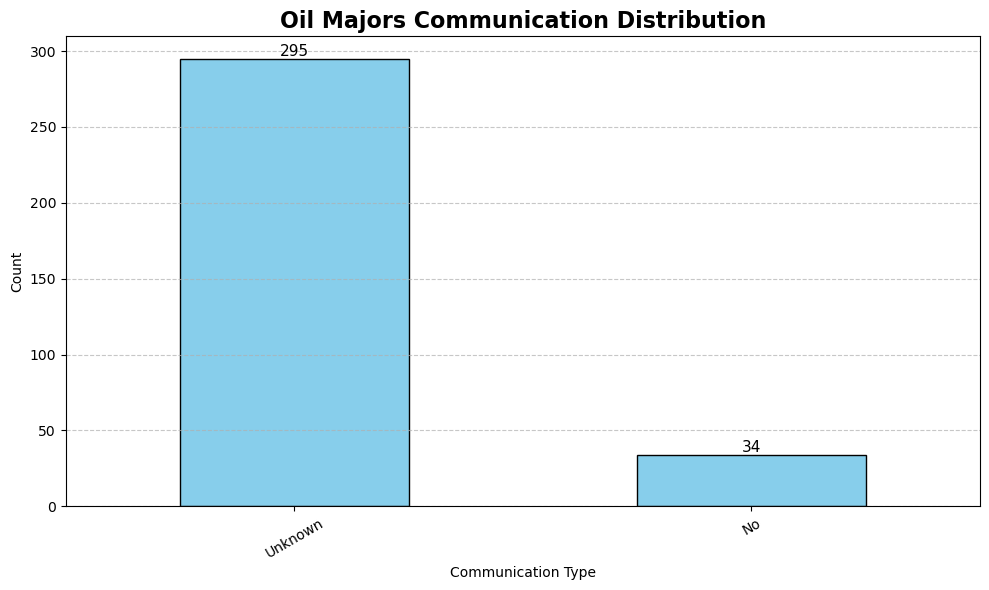

In [462]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

counts = data['Oil Majors Communication'].value_counts()

ax = counts.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title("Oil Majors Communication Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Communication Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [447]:
data.groupby('ship Name')['Near Miss Total'].sum().sort_values(ascending=False).head(10)

ship Name
KM HAKATA         213.0
SABARIMALA GAS    169.0
SRI VISHNU        152.0
FUJI GAS          149.0
TIRUMALA GAS      124.0
OCCITAN KEY       121.0
PALANIMALA GAS    112.0
SEROJA ENAM       105.0
TAKAO GAS         103.0
NANYANG STAR      102.0
Name: Near Miss Total, dtype: float64

In [448]:
data['Risk Score'] = (
    data['Near Miss Total'] +
    data['ADI Total'] +
    data['Larp Unsafe Act']
)

In [449]:
data['Incident Frequency'] = data['Total Incidents'] / (data['Ship Lifetime Months'] + 1)

In [450]:
data['Reporting Efficiency'] = data['Near Miss Report'] / (data['Near Miss Count'] + 1)

In [451]:
def risk_level(x):
    if x > 20:
        return 'High'
    elif x > 10:
        return 'Medium'
    else:
        return 'Low'

data['Risk Level'] = data['Risk Score'].apply(risk_level)

C:\Users\dhana\AppData\Local\Temp\ipykernel_15712\789149152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


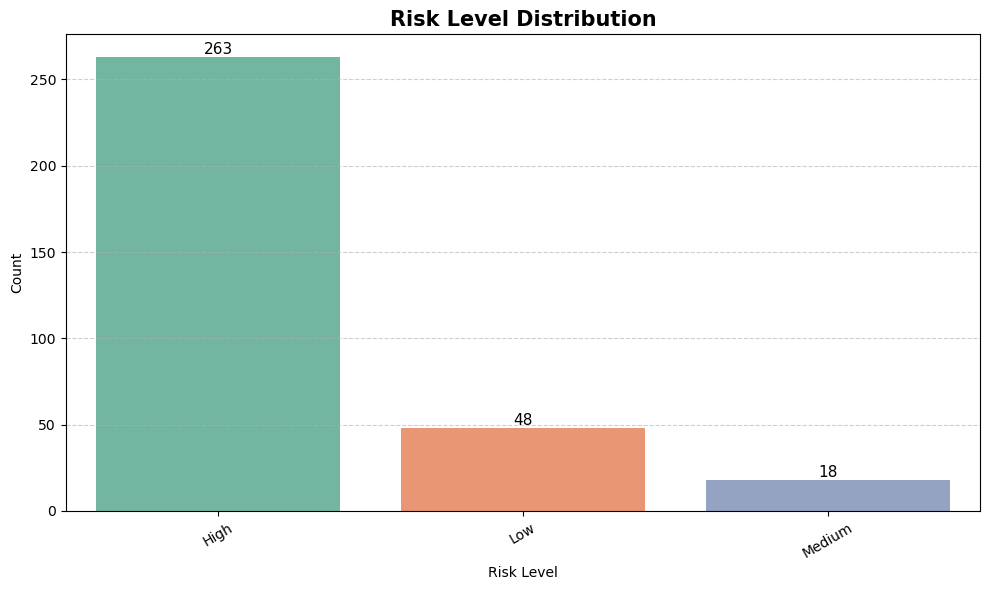

In [464]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    x='Risk Level',
    data=data,
    order=data['Risk Level'].value_counts().index,
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title("Risk Level Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

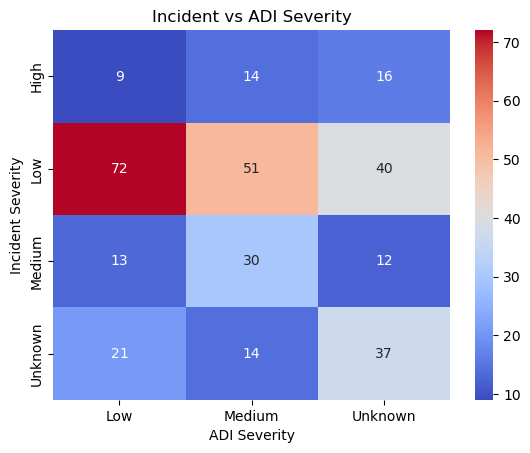

In [453]:
sns.heatmap(pd.crosstab(
    data['Incident Severity'],
    data['ADI Severity']
), annot=True, cmap='coolwarm')

plt.title("Incident vs ADI Severity")
plt.show()

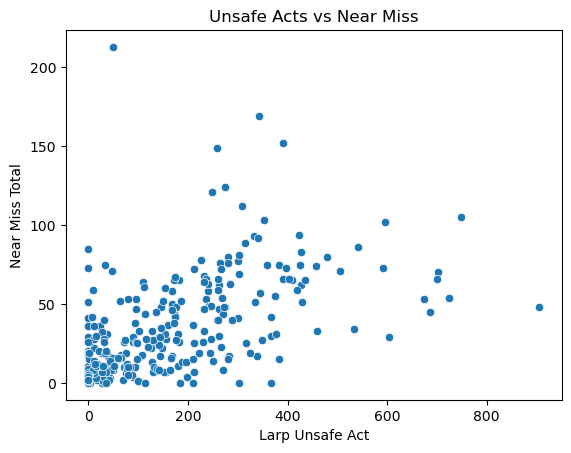

In [454]:
sns.scatterplot(
    x='Larp Unsafe Act',
    y='Near Miss Total',
    data=data
)
plt.title("Unsafe Acts vs Near Miss")
plt.show()

C:\Users\dhana\AppData\Local\Temp\ipykernel_15712\2476393604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


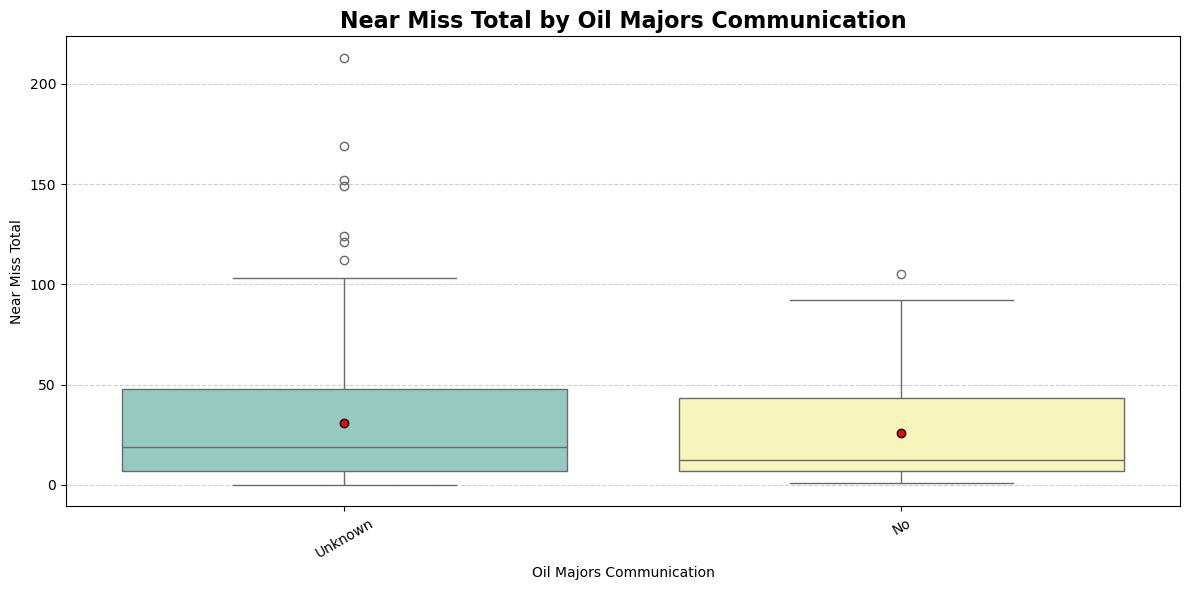

In [465]:
plt.figure(figsize=(12,6))

ax = sns.boxplot(
    x='Oil Majors Communication',
    y='Near Miss Total',
    data=data,
    palette='Set3',
    showmeans=True,
    meanprops={"marker":"o",
               "markerfacecolor":"red",
               "markeredgecolor":"black",
               "markersize":"6"}
)

plt.title("Near Miss Total by Oil Majors Communication", fontsize=16, fontweight='bold')
plt.xlabel("Oil Majors Communication")
plt.ylabel("Near Miss Total")
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

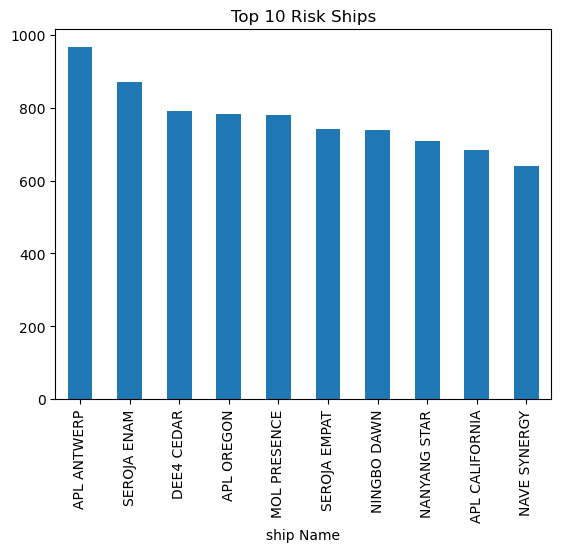

In [456]:
top_ships = data.groupby('ship Name')['Risk Score'].sum().sort_values(ascending=False).head(10)

top_ships.plot(kind='bar')
plt.title("Top 10 Risk Ships")
plt.show()

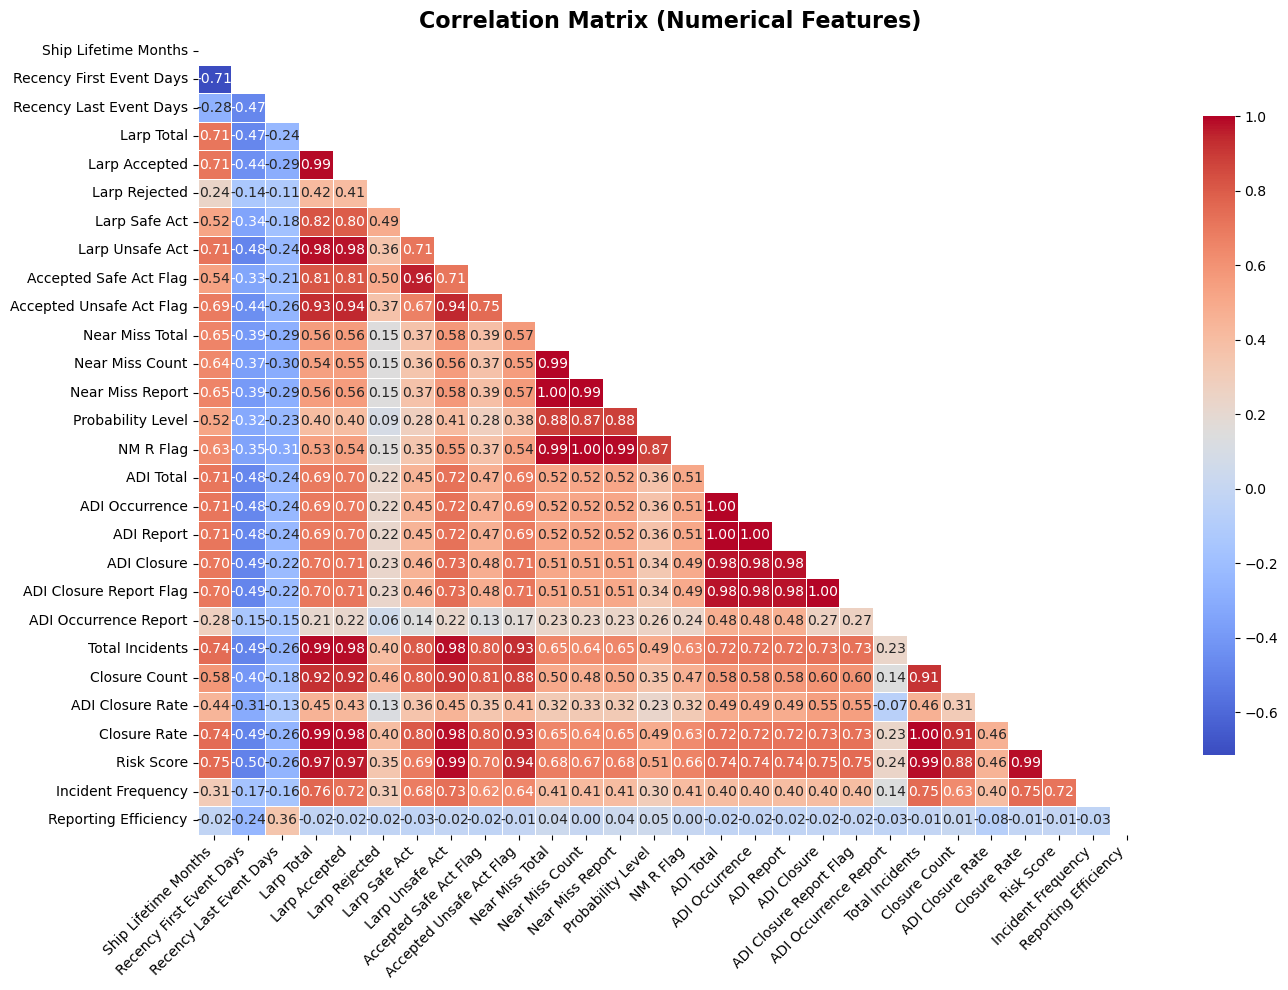

In [466]:
plt.figure(figsize=(14,10))

corr = data.select_dtypes(include=['int64','float64']).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,         
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Numerical Features)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [467]:
data.columns

Index(['Name of Ship', 'First Event of Ship', 'Last Event of Ship',
       'Ship Lifetime Months', 'Recency First Event Days',
       'Recency Last Event Days', 'Larp Total', 'Larp Accepted',
       'Larp Rejected', 'Larp Safe Act', 'Larp Unsafe Act',
       'Accepted Safe Act Flag', 'Accepted Unsafe Act Flag', 'Near Miss Total',
       'Near Miss Count', 'Near Miss Report', 'Probability Level', 'NM R Flag',
       'ADI Total', 'ADI Occurrence', 'ADI Report', 'ADI Closure',
       'ADI Closure Report Flag', 'ADI Occurrence Report', 'Total Incidents',
       'Closure Count', 'ship Name', 'Incident Severity',
       'Incident Probability', 'Incident Potential', 'Learning Potential',
       'Further Investigation', 'Oil Majors Communication',
       'External Reporting Required', 'Industry Shared', 'ADI Closure Rate',
       'ADI Severity', 'ADI Recurrence', 'ADI Incident Category',
       'ADI Learning Potential', 'ADI Injury Category', 'Closure Rate',
       'Risk Score', 'Incident Freq

In [468]:
target = 'Risk Level'

In [469]:
features = [
    'Ship Lifetime Months',
    'Recency First Event Days',
    'Recency Last Event Days',
    'Larp Total',
    'Larp Accepted',
    'Larp Rejected',
    'Near Miss Total',
    'ADI Total',
    'Total Incidents',
    'Closure Rate',
    'Risk Score',
    'Incident Frequency',
    'Reporting Efficiency'
]

In [470]:
from sklearn.model_selection import train_test_split

X = data[features]
y = data[target]

X = X.fillna(0)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [471]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [472]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [473]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9848484848484849
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.89      1.00      0.94         8
           2       1.00      0.75      0.86         4

    accuracy                           0.98        66
   macro avg       0.96      0.92      0.93        66
weighted avg       0.99      0.98      0.98        66



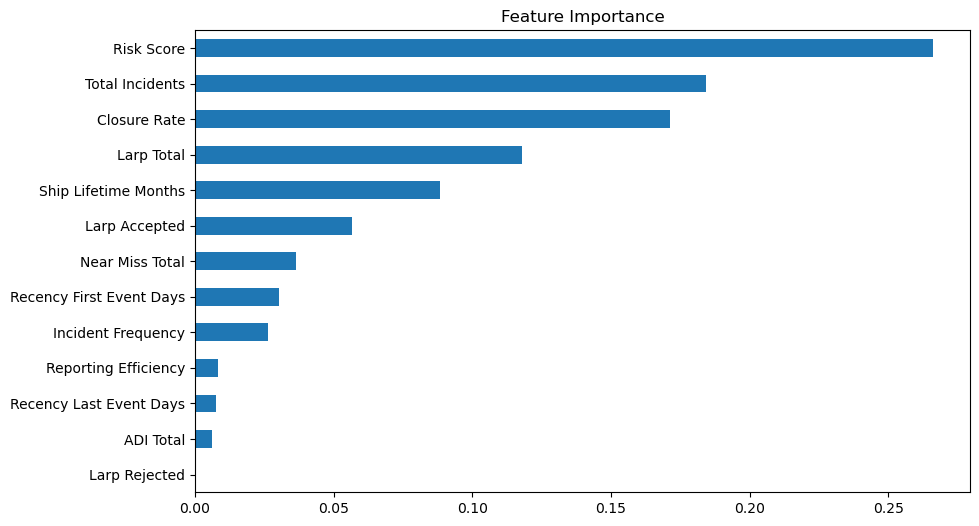

In [474]:

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()